# L12d: Predicting Antibody Production in Fed-Batch CHO Bioreactors with LSTMs
In this lab, we use an LSTM network to predict the full state trajectory of a fed-batch CHO bioreactor at different initial glutamine concentrations. Glutamine is a key nitrogen source for CHO cells; varying its initial level changes the growth phase duration, by-product accumulation, and antibody production. We generate training data by simulating a kinetic CHO model, train an LSTM, and evaluate predictions across a range of glutamine levels.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Generate CHO bioreactor data at different glutamine levels:__ Use a kinetic fed-batch CHO model with [`generate_cho_glutamine_dataset(...)`](src/Simulation.jl) to simulate bioreactor trajectories at different initial glutamine concentrations.
> * __Train an LSTM for conditional multi-state time series prediction:__ Implement teacher forcing training where the LSTM receives the current bioreactor state and the glutamine level as input and predicts all seven states at the next time step.
> * __Evaluate LSTM predictions across bioprocess conditions:__ Compare predicted and actual bioreactor trajectories across low, medium, and high glutamine levels and assess whether the LSTM captures the coupled dynamics of growth, consumption, and production.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-12/L12d`
    Updating `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-12/L12d/Project.toml`
  [a93c6f00] + DataFrames v1.8.1
  [587475ba] + Flux v0.16.9
  [7073ff75] + IJulia v1.34.4
  [033835bb] + JLD2 v0.6.4
  [872c559c] + NNlib v0.9.33
  [1dea7af3] + OrdinaryDiffEq v6.111.0
  [91a5bcdd] + Plots v1.41.6
  [08abe8d2] + PrettyTables v3.3.2
  [10745b16] + Statistics v1.11.1
  [37e2e46d] ~ LinearAlgebra ⇒ v1.12.0
  [9a3f8284] ~ Random ⇒ v1.11.0
    Updating `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-12/L12d/Manifest.toml`
  [47edcb42] + ADTypes v1.21.0
  [621f4979] + AbstractFFTs v1.5.0
  [7d9f7c33] + Accessors v0.1.44
  [79e6a3ab] + Adapt v4.5.0
  [66dad0bd] + AliasTables v1.1.3
  [dce04be8] + ArgCheck v2.5.0
  [4fba245c] + ArrayInterface v7.23.0
  [a9b6321e] + Atomix v1.1.3
  [

In addition to standard Julia libraries, this lab uses [the `OrdinaryDiffEq.jl` package](https://github.com/SciML/OrdinaryDiffEq.jl) for solving the CHO bioreactor ODE system and [the `Flux.jl` package](https://fluxml.ai/Flux.jl/stable/) for gradient computation and optimization. The CHO kinetic model is implemented from scratch in the `src/` directory.

### Implementations
We use helper functions defined in the `src/` directory:

| Function | Source | Description |
| --- | --- | --- |
| [`build_default_parameters(...)`](src/Parameters.jl) | `src/Parameters.jl` | Construct CHO model parameters for a given feed policy |
| [`growth_rate(...)`](src/Kinetics.jl) | `src/Kinetics.jl` | Monod growth rate with by-product inhibition |
| [`simulate_fedbatch(...)`](src/Simulation.jl) | `src/Simulation.jl` | Solve the fed-batch CHO ODE system with feed callbacks |
| [`generate_cho_glutamine_dataset(...)`](src/Simulation.jl) | `src/Simulation.jl` | Generate CHO datasets at different initial glutamine levels |
| [`normalize_minmax_perstate(...)`](src/Simulation.jl) | `src/Simulation.jl` | Per-state normalization using training bounds |
| [`denormalize_minmax(...)`](src/Simulation.jl) | `src/Simulation.jl` | Reverse per-state normalization |
| [`build_lstm(...)`](src/LSTM.jl) | `src/LSTM.jl` | Initialize an LSTM with Xavier-scaled weights |
| [`forward_step(...)`](src/LSTM.jl) | `src/LSTM.jl` | Compute one LSTM time step |
| [`forward_sequence(...)`](src/LSTM.jl) | `src/LSTM.jl` | Run the LSTM over a full sequence with teacher forcing |
| [`predict_sequence(...)`](src/LSTM.jl) | `src/LSTM.jl` | Generate a predicted sequence via autoregressive rollout |
| [`count_parameters(...)`](src/LSTM.jl) | `src/LSTM.jl` | Count total trainable parameters |

### Background: CHO Cell Culture and Glutamine Metabolism

> __Glutamine in CHO cell culture__ is a key carbon and nitrogen source that drives cell growth through the TCA cycle. Higher initial glutamine concentrations support faster initial growth but also produce more ammonia through glutaminolysis. Ammonia accumulation inhibits growth at high levels, creating a trade-off that shapes the entire fermentation trajectory. In this lab, we simulate bioreactor trajectories at initial glutamine concentrations ranging from 1 mM to 8 mM to capture this trade-off.
>
> The bioreactor model tracks seven states: volume (V), biomass (X), glucose (S_glc), glutamine (S_gln), antibody product (P), lactate (Lac), and ammonia (Amm). A glucose-triggered feed provides nutrients when glucose drops below a threshold.

### Constants
We define simulation and training constants used throughout the lab. The simulation constants control the glutamine range and time resolution, while the LSTM constants specify the network architecture and training hyperparameters.

In [2]:
# simulation constants -
number_of_curves = 50;           # total number of glutamine levels to simulate
gln_min = 1.0;                   # minimum initial glutamine (mM)
gln_max = 8.0;                   # maximum initial glutamine (mM)
tspan = (0.0, 240.0);           # simulation time span: 0 to 240 hours (10 days)
saveat = 1.0;                    # save ODE solution every 1 hour (241 time points)

# state labels for plotting -
state_labels = ["V (L)", "X (gDW/L)", "Glc (mM)", "Gln (mM)", "mAb (mg/L)", "Lac (mM)", "Amm (mM)"];

# LSTM architecture constants -
d_in = 8;                        # input dimension: 7 states + 1 conditioning (glutamine)
h_dim = 128;                     # hidden state dimension
d_out = 7;                       # output dimension: predict all 7 states

# training constants -
num_epochs = 500;                # number of training epochs
learning_rate = 1e-3;            # Adam optimizer learning rate
train_fraction = 0.8;            # fraction of curves used for training (80% train, 20% test)
grad_clip = 1.0;                 # gradient clipping threshold (max gradient norm)

___

## Task 1: Generate CHO Bioreactor Data
We use the kinetic CHO model to generate bioreactor trajectories at different initial glutamine concentrations. [The `generate_cho_glutamine_dataset(...)` function](src/Simulation.jl) simulates the fed-batch model at each glutamine level with a fixed glucose-triggered feed policy.

> __Glutamine titration__
>
> Increasing initial glutamine supports faster cell growth by providing nitrogen for biosynthesis, but also increases ammonia accumulation through glutaminolysis. At high ammonia levels, growth is inhibited. This creates distinct trajectory shapes: low glutamine produces slow growth with low ammonia, while high glutamine produces fast initial growth followed by ammonia-mediated growth inhibition.

Generate 50 bioreactor trajectories at glutamine concentrations linearly spaced from 1 mM to 8 mM using [the `range(...)` function](https://docs.julialang.org/en/v1/base/math/#Base.range). The simulation results should be stored in the `time_vector::Vector{Float64}` variable (time points in hours), the `state_arrays::Vector{Matrix{Float64}}` variable (each element is a T x 7 matrix of states), and the `gln_values::Vector{Float64}` variable (initial glutamine concentrations in mM).

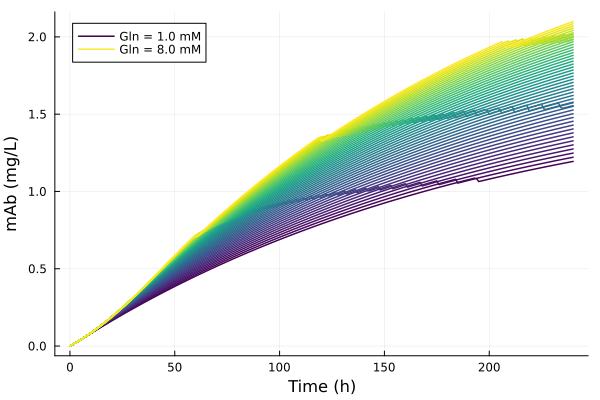

In [3]:
time_vector, state_arrays, gln_values = let

    # generate initial glutamine levels linearly spaced from gln_min to gln_max -
    gln_values = collect(range(gln_min, gln_max, length=number_of_curves));

    # simulate the CHO model at each glutamine level -
    time_vector, state_arrays, gln_values = generate_cho_glutamine_dataset(gln_values;
        tspan=tspan, saveat=saveat);

    # plot all antibody production curves (state column 5) colored by glutamine level -
    colors = palette(:viridis, number_of_curves);
    p = plot(xlabel="Time (h)", ylabel="mAb (mg/L)", legend=:topleft);
    for j in 1:number_of_curves
        if j == 1
            plot!(p, time_vector, state_arrays[j][:, 5], color=colors[j], lw=1.5,
                label="Gln = $(round(gln_values[j], digits=1)) mM")
        elseif j == number_of_curves
            plot!(p, time_vector, state_arrays[j][:, 5], color=colors[j], lw=1.5,
                label="Gln = $(round(gln_values[j], digits=1)) mM")
        else
            plot!(p, time_vector, state_arrays[j][:, 5], color=colors[j], lw=1.5, label="")
        end
    end
    display(p)

    # return -
    (time_vector, state_arrays, gln_values)
end;

The curves should show that higher initial glutamine supports more cell growth and antibody production, but also produces more ammonia.

Next, we normalize the data per-state using bounds computed from the training set only, using [the `normalize_minmax_perstate(...)` function](src/Simulation.jl), and split into training and test sets using [the `randperm(...)` function](https://docs.julialang.org/en/v1/stdlib/Random/#Random.randperm). The normalized state arrays are stored in `X_norm_arrays`, the per-state bounds in `state_mins` and `state_maxs`, the normalized glutamine values in `gln_norm`, and the training and test indices in `train_idx` and `test_idx`.

In [4]:
X_norm_arrays, state_mins, state_maxs, gln_norm, gln_norm_min, gln_norm_max, train_idx, test_idx = let

    # shuffle and split into train/test sets -
    Random.seed!(42);
    perm = randperm(number_of_curves);
    n_train = Int(round(train_fraction * number_of_curves));
    train_idx = perm[1:n_train];
    test_idx = perm[(n_train+1):end];

    # normalize states per-state using training bounds only -
    X_norm_arrays, state_mins, state_maxs = normalize_minmax_perstate(state_arrays, train_idx);

    # normalize glutamine values to [0, 1] using training bounds -
    gln_norm_min = minimum(gln_values[train_idx]);
    gln_norm_max = maximum(gln_values[train_idx]);
    gln_norm = (gln_values .- gln_norm_min) ./ (gln_norm_max - gln_norm_min);

    # print dataset summary -
    println("Dataset: $(number_of_curves) curves, $(size(state_arrays[1], 1)) time points each");
    println("Training: $(length(train_idx)) curves, Test: $(length(test_idx)) curves");
    println("Glutamine range: $(gln_min) to $(gln_max) mM");

    # return all outputs -
    (X_norm_arrays, state_mins, state_maxs, gln_norm, gln_norm_min, gln_norm_max, train_idx, test_idx)
end;

Dataset: 50 curves, 241 time points each
Training: 40 curves, Test: 10 curves
Glutamine range: 1.0 to 8.0 mM


### Things to think about
* __Why linear spacing for glutamine?__ Unlike tissue factor or FVIII levels which span orders of magnitude, the glutamine range (1 to 8 mM) is within one order of magnitude. Linear spacing provides uniform coverage.
* __Why per-state normalization?__ The seven bioreactor states have very different scales (volume in L, glucose in mM, antibody in mg/L). Per-state normalization ensures the MSE loss weights each state proportionally.

___

## Task 2: Build and Train the LSTM
We construct and train an LSTM for autoregressive multi-state prediction. At each time step, the LSTM receives the input $\mathbf{x}_t = [\mathbf{s}_t; c] \in \mathbb{R}^{8}$ where $\mathbf{s}_t$ is the normalized state vector and $c$ is the normalized initial glutamine level, and predicts $\hat{\mathbf{s}}_{t+1} \in \mathbb{R}^{7}$.

> __LSTM gate equations (from L12c lecture)__
>
> $$
\begin{align*}
\mathbf{f}_t &= \sigma(\mathbf{W}_f \mathbf{x}_t + \mathbf{U}_f \mathbf{h}_{t-1} + \mathbf{b}_f) \\
\mathbf{i}_t &= \sigma(\mathbf{W}_i \mathbf{x}_t + \mathbf{U}_i \mathbf{h}_{t-1} + \mathbf{b}_i) \\
\tilde{\mathbf{c}}_t &= \tanh(\mathbf{W}_c \mathbf{x}_t + \mathbf{U}_c \mathbf{h}_{t-1} + \mathbf{b}_c) \\
\mathbf{c}_t &= \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t \\
\mathbf{o}_t &= \sigma(\mathbf{W}_o \mathbf{x}_t + \mathbf{U}_o \mathbf{h}_{t-1} + \mathbf{b}_o) \\
\mathbf{h}_t &= \mathbf{o}_t \odot \tanh(\mathbf{c}_t) \\
\mathbf{y}_t &= \sigma(\mathbf{V}_y \mathbf{h}_t + \mathbf{b}_y)
\end{align*}
> $$
>
> The model is trained with teacher forcing: at each step, the true previous state is provided as input. The loss is mean squared error between predictions and targets, averaged over all time steps and states. We use [the `Flux.withgradient(...)` function](https://fluxml.ai/Flux.jl/stable/training/training/#Flux.withgradient-Tuple{Any,%20Vararg{Any}}) for gradient computation and [the `Adam` optimizer](https://fluxml.ai/Flux.jl/stable/training/optimisers/#Flux.Optimise.Adam) for parameter updates.

We use [the `build_lstm(...)` function](src/LSTM.jl) to initialize the model. The model is stored in the `model::MyLSTMModel` variable.

In [5]:
model = let

    # build the LSTM with d_in=8, h=128, d_out=7 -
    model = build_lstm(d_in, h_dim, d_out; seed=42);
    println("LSTM: d_in=$(d_in), h=$(h_dim), d_out=$(d_out)");
    println("Total parameters: $(count_parameters(model))");

    # return initialized model -
    model
end;

LSTM: d_in=8, h=128, d_out=7
Total parameters: 71047


Now, train the model. Use [`OptimiserChain`](https://fluxml.ai/Optimisers.jl/dev/api/#Optimisers.OptimiserChain) to combine [`ClipGrad`](https://fluxml.ai/Optimisers.jl/dev/api/#Optimisers.ClipGrad) with [`Adam`](https://fluxml.ai/Flux.jl/stable/training/optimisers/#Flux.Optimise.Adam) for gradient clipping. The per-epoch average MSE loss values should be stored in the `loss_history::Vector{Float64}` variable. Use [the `forward_sequence(...)` function](src/LSTM.jl) for the teacher forcing forward pass and [the `Flux.update!(...)` function](https://fluxml.ai/Flux.jl/stable/training/training/#Flux.update!) to apply gradient updates.

In [6]:
loss_history = let

    # check for a pre-trained model checkpoint -
    checkpoint_path = joinpath(_ROOT, "data", "lstm_best_model.jld2");
    if isfile(checkpoint_path)
        println("Loading pre-trained model from $(checkpoint_path)");
        checkpoint = JLD2.load(checkpoint_path);
        Flux.loadmodel!(model, checkpoint["model_state"]);
        history = checkpoint["loss_history"];
        println("Loaded model with $(length(history)) epochs, best loss = $(round(minimum(history), sigdigits=4))");
    else

        # initialize optimizer with gradient clipping -
        opt_state = Flux.setup(OptimiserChain(ClipGrad(grad_clip), Adam(learning_rate)), model);
        history = Vector{Float64}();   # stores average loss per epoch
        T = size(X_norm_arrays[1], 1); # number of time points per curve
        best_loss = Inf;               # track best loss for checkpointing

        # training loop -
        for epoch in 1:num_epochs
            epoch_loss = 0.0;

            # iterate over each training condition -
            for idx in train_idx

                # prepare this condition's data -
                curve = X_norm_arrays[idx];       # T x 7 matrix of normalized states
                cond_vec = [gln_norm[idx]];        # length-1 normalized conditioning vector
                targets = curve[2:end, :];         # (T-1) x 7 matrix of true next states

                # compute MSE loss and gradients -
                loss_val, grads = Flux.withgradient(model) do m
                    preds, _ = forward_sequence(m, curve, cond_vec);
                    sum((preds .- targets) .^ 2) / ((T - 1) * d_out)
                end

                # apply gradient update -
                Flux.update!(opt_state, model, grads[1]);
                epoch_loss += loss_val;
            end

            # record average loss for this epoch -
            avg_loss = epoch_loss / length(train_idx);
            push!(history, avg_loss);

            # save model checkpoint at new best loss -
            if avg_loss < best_loss
                best_loss = avg_loss;
                JLD2.jldsave(checkpoint_path;
                    model_state = Flux.state(model),
                    loss_history = history
                );
            end

            # print progress every 100 epochs -
            if epoch % 100 == 0 || epoch == 1
                println("Epoch $(epoch)/$(num_epochs): loss = $(round(avg_loss, sigdigits=4)), best = $(round(best_loss, sigdigits=4))");
            end
        end
    end

    # return the loss history -
    history
end;

Epoch 1/500: loss = 0.01946, best = 0.01946
Epoch 100/500: loss = 0.0001991, best = 0.0001991
Epoch 200/500: loss = 0.0001202, best = 0.000109
Epoch 300/500: loss = 0.000104, best = 7.043e-5
Epoch 400/500: loss = 7.446e-5, best = 4.175e-5
Epoch 500/500: loss = 6.551e-5, best = 3.772e-5


Let's plot the training loss to verify convergence.

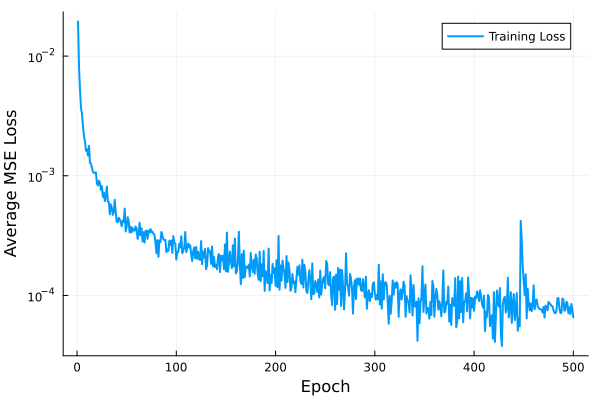

In [7]:
let
    # plot loss history on log scale to visualize convergence -
    plot(1:length(loss_history), loss_history, xlabel="Epoch", ylabel="Average MSE Loss",
        label="Training Loss", lw=2, yscale=:log10)
end

### Things to think about
* __How does the LSTM cell state help with bioreactor dynamics?__ The cell state can store information about the phase of the culture (lag, exponential, stationary, decline) that persists across many time steps.
* __Why does multi-state prediction matter?__ The seven states are coupled through the kinetics. Predicting all states simultaneously forces the LSTM to learn these couplings.

___

## Task 3: Evaluate Predictions on Test Curves
We evaluate the trained LSTM on held-out glutamine levels using autoregressive rollout. [The `predict_sequence(...)` function](src/LSTM.jl) starts from the true initial state vector $\mathbf{s}_0$ and feeds the model's own predictions back as input at each subsequent step. We use [the `denormalize_minmax(...)` function](src/Simulation.jl) to convert predictions back to original scales.

> __Autoregressive evaluation for multi-state systems__
>
> During autoregressive rollout, errors in any predicted state propagate to all other states through the shared hidden representation. For the bioreactor, an error in glucose prediction affects the predicted growth rate, which affects biomass, product, and by-product predictions. This cascading effect makes multi-state evaluation more challenging than single-state evaluation.

Generate predictions for the test curves and compare to ground truth. Plot the antibody titer (state 5) for 4 representative test curves.

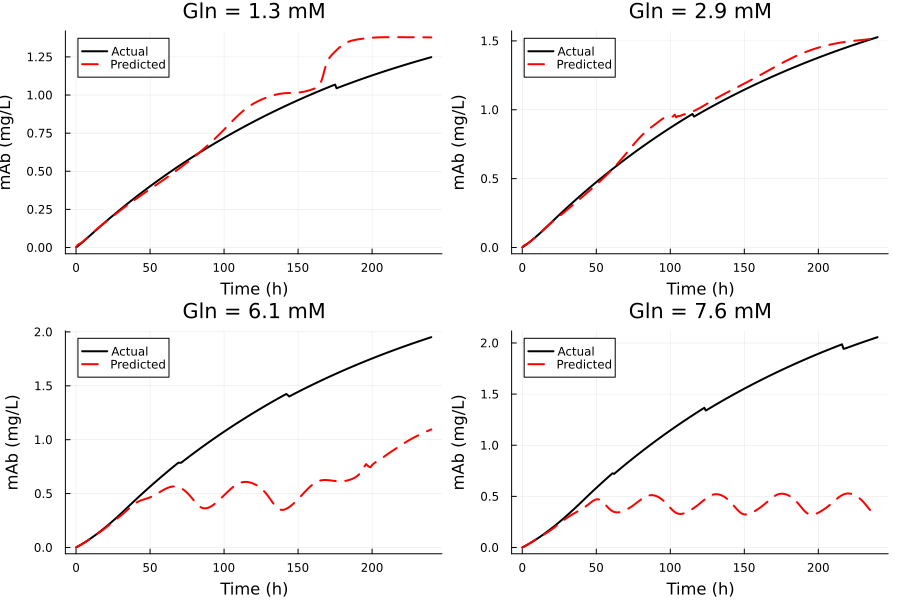

In [8]:
let

    # sort test indices by glutamine level -
    sorted_test = sort(test_idx, by=i -> gln_values[i]);

    # select up to 4 evenly-spaced curves for plotting -
    n_plots = min(length(test_idx), 4);
    plot_indices = sorted_test[round.(Int, range(1, length(test_idx), length=n_plots))];

    # generate predictions and plot antibody titer for each selected test curve -
    T = size(X_norm_arrays[1], 1);
    plots_array = [];
    for idx in plot_indices

        # autoregressive prediction -
        x_0_vec = X_norm_arrays[idx][1, :];
        cond_vec = [gln_norm[idx]];
        pred_norm = predict_sequence(model, x_0_vec, cond_vec, T);

        # convert to original scale -
        pred_real = denormalize_minmax(pred_norm, state_mins, state_maxs);
        actual_real = state_arrays[idx];

        # plot antibody titer (column 5): actual vs predicted -
        p = plot(time_vector, actual_real[:, 5], label="Actual", lw=2, color=:black);
        plot!(p, time_vector, pred_real[:, 5], label="Predicted", lw=2, color=:red, ls=:dash);
        plot!(p, xlabel="Time (h)", ylabel="mAb (mg/L)",
            title="Gln = $(round(gln_values[idx], digits=1)) mM");
        push!(plots_array, p);
    end

    # combine into a 2x2 grid -
    plot(plots_array..., layout=(2, 2), size=(900, 600))
end

Let's build a comparison table of bioprocess metrics for all test curves. We compare the final antibody titer, maximum biomass, and per-condition MSE (on the normalized scale) using [the `maximum(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.maximum) and [the `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean).

In [9]:
let

    # initialize -
    T = size(X_norm_arrays[1], 1);
    rows = [];

    # iterate over test curves sorted by glutamine level -
    for idx in sort(test_idx, by=i -> gln_values[i])

        # generate autoregressive prediction -
        x_0_vec = X_norm_arrays[idx][1, :];
        cond_vec = [gln_norm[idx]];
        pred_norm = predict_sequence(model, x_0_vec, cond_vec, T);

        # convert to original scale -
        pred_real = denormalize_minmax(pred_norm, state_mins, state_maxs);
        actual_real = state_arrays[idx];

        # compute metrics -
        actual_titer = actual_real[end, 5];       # final antibody titer (mg/L)
        pred_titer = pred_real[end, 5];            # predicted final titer (mg/L)
        actual_max_X = maximum(actual_real[:, 2]); # max biomass (gDW/L)
        pred_max_X = maximum(pred_real[:, 2]);     # predicted max biomass (gDW/L)

        # MSE on normalized scale to match training loss -
        actual_norm = X_norm_arrays[idx];
        mse = mean((pred_norm .- actual_norm) .^ 2);

        # add row to table -
        push!(rows, (
            Gln_mM = round(gln_values[idx], digits=1),
            Actual_Titer = round(actual_titer, digits=1),
            Pred_Titer = round(pred_titer, digits=1),
            Actual_maxX = round(actual_max_X, digits=2),
            Pred_maxX = round(pred_max_X, digits=2),
            MSE = round(mse, sigdigits=4)
        ));
    end

    # display as a formatted table -
    df = DataFrame(rows);
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 --------- -------------- ------------ ------------- ----------- ----------
   Gln_mM   Actual_Titer   Pred_Titer   Actual_maxX   Pred_maxX        MSE 
  Float64        Float64      Float64       Float64     Float64    Float64 
 --------- -------------- ------------ ------------- ----------- ----------
      1.3            1.2          1.4          0.59        0.59   0.005312
      1.9            1.4          1.5          0.63        0.62   0.006123
      2.1            1.4          1.5          0.65        0.64   0.005864
      2.9            1.5          1.5           0.7        0.69   0.003302
      3.6            1.6          1.5          0.74        0.74   0.001827
      5.3            1.8          0.5          0.84        0.83     0.1094
      6.1            2.0          1.1          0.87        0.88    0.09448
      6.3            2.0          1.2          0.88        0.88    0.08797
      7.0            2.0          0.5          0.91        0.91     0.1516
      7.6            

### Things to think about
* __Where does the model perform best and worst?__ Consider whether the LSTM captures the dynamics better at low, medium, or high glutamine. Why might some regions be harder to predict?
* __How does multi-state error accumulation differ from single-state?__ Compare the error patterns here to the single-output Elman RNN predictions in the L12b lab.

___

## Task 4: Bioprocess Interpretation
We select three representative glutamine levels (low, medium, high) and compare the LSTM predictions for all seven states side-by-side to visualize how the model captures the coupled bioreactor dynamics.

> __Coupled dynamics in fed-batch culture__
>
> The seven bioreactor states are tightly coupled through the growth kinetics: cell growth consumes glucose and glutamine, produces lactate and ammonia as by-products, and antibody production depends on viable biomass. Accurate prediction of any single state requires the LSTM to correctly capture all of these couplings.

We use [the `predict_sequence(...)` function](src/LSTM.jl) to generate autoregressive predictions and [the `denormalize_minmax(...)` function](src/Simulation.jl) to convert back to original scales. We find the nearest curve to each target glutamine level using [the `argmin(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.argmin).

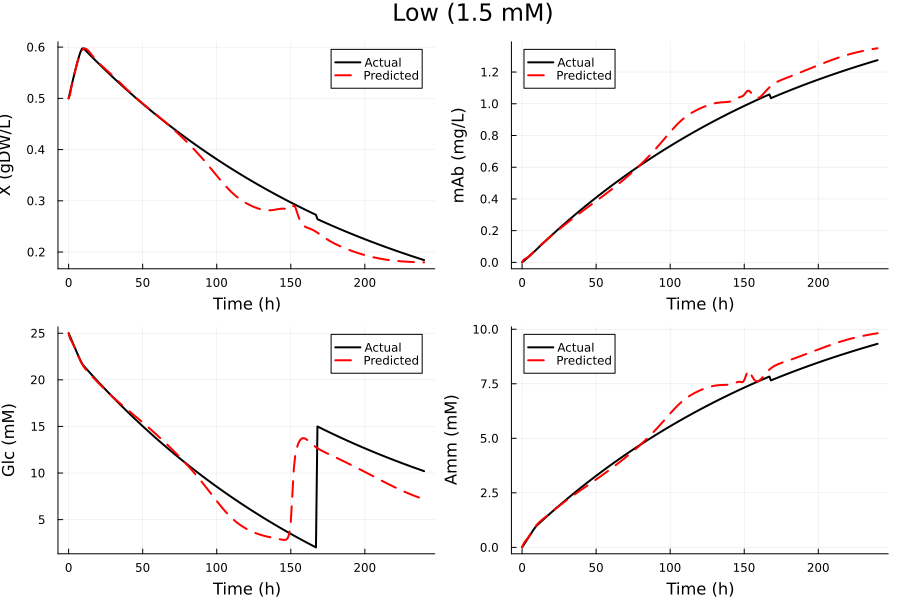

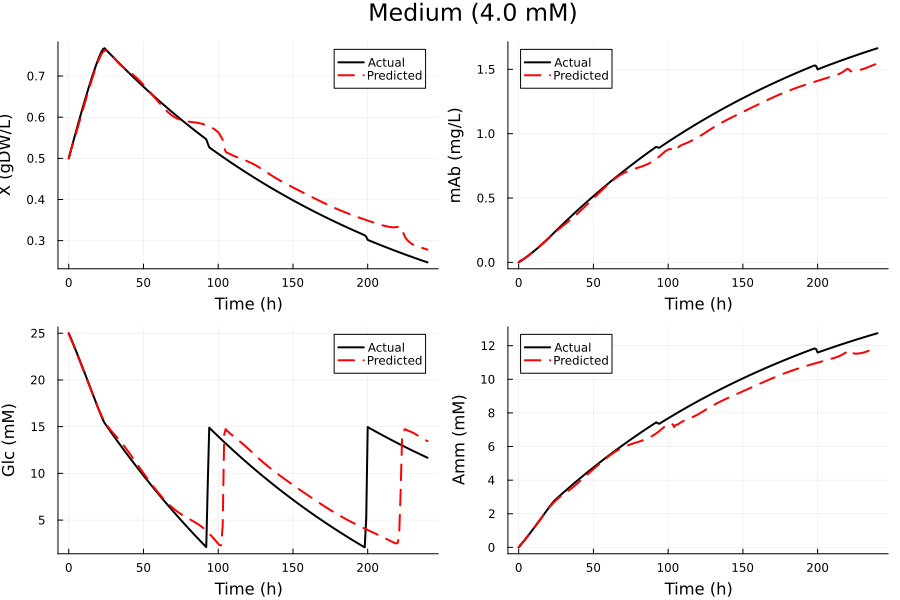

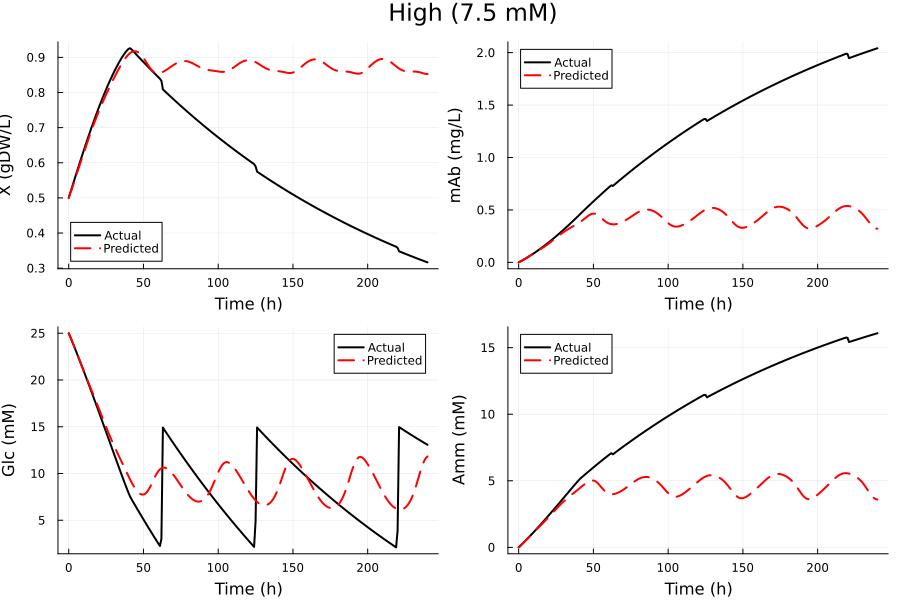

In [10]:
let

    # define representative glutamine levels -
    target_levels = [1.5, 4.0, 7.5];                                  # mM
    level_labels = ["Low (1.5 mM)", "Medium (4.0 mM)", "High (7.5 mM)"];
    T = size(X_norm_arrays[1], 1);

    # select which states to plot: biomass (2), antibody (5), glucose (3), ammonia (7) -
    plot_states = [2, 5, 3, 7];
    plot_ylabels = ["X (gDW/L)", "mAb (mg/L)", "Glc (mM)", "Amm (mM)"];

    # generate predictions for each glutamine level -
    for (k, target) in enumerate(target_levels)

        # find the curve closest to this target glutamine level -
        idx = argmin(abs.(gln_values .- target));

        # autoregressive prediction -
        x_0_vec = X_norm_arrays[idx][1, :];
        cond_vec = [gln_norm[idx]];
        pred_norm = predict_sequence(model, x_0_vec, cond_vec, T);

        # convert to original scale -
        pred_real = denormalize_minmax(pred_norm, state_mins, state_maxs);
        actual_real = state_arrays[idx];

        # plot 4 key states in a 2x2 grid -
        plots_array = [];
        for (s, si) in enumerate(plot_states)
            p = plot(time_vector, actual_real[:, si], label="Actual", lw=2, color=:black);
            plot!(p, time_vector, pred_real[:, si], label="Predicted", lw=2, color=:red, ls=:dash);
            plot!(p, xlabel="Time (h)", ylabel=plot_ylabels[s]);
            push!(plots_array, p);
        end
        display(plot(plots_array..., layout=(2, 2), size=(900, 600),
            plot_title=level_labels[k]))
    end
end

### Things to think about
* __Can the LSTM capture the glucose cycling from the feed?__ The glucose-triggered feed creates oscillatory patterns. Assess whether the LSTM reproduces these oscillations or smooths them out.
* __How does ammonia accumulation affect prediction quality?__ At high glutamine levels, ammonia builds up and inhibits growth. Does the LSTM correctly capture this feedback?
* __What are the limitations of this approach?__ Consider factors not captured by the kinetic model (cell line variability, media batch effects, dissolved oxygen) and how they might affect real-world predictions.

___

## Summary
In this lab, we simulated fed-batch CHO bioreactor trajectories at varying initial glutamine concentrations, trained an LSTM to predict all seven bioreactor states, and evaluated predictions across a range of conditions.

> __Key Takeaways:__
>
> * **Kinetic ODE models provide multi-state training data for bioprocess prediction:** The fed-batch CHO model generates seven coupled state trajectories that vary systematically with initial glutamine, providing a controlled dataset for training and evaluating multi-output LSTM models.
> * **LSTMs learn coupled dynamics from simulation data:** By conditioning on the glutamine level, the LSTM learns to predict the full bioreactor state trajectory across different growth conditions using a single trained model.
> * **Multi-state autoregressive rollout reveals coupling errors:** Prediction errors propagate across coupled states during rollout, highlighting the challenge of multi-output time series prediction and the importance of capturing inter-state dependencies.

For more on LSTM architecture and gating mechanisms, see the [L12c lecture on LSTM Networks](../../../CHEME-5820-Lectures-Spring-2026/lectures/week-12/L12c/CHEME-5820-L12c-Lecture-LSTM-Spring-2026.ipynb).
___